# IsoFLOP Analysis

`data/isoflops_curves.json`의 IsoFLOP 프로파일로 Chinchilla Method 2를 재현한다.

## 데이터 로드

In [1]:
import json

import pandas as pd

with open("../data/isoflops_curves.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(len(df), "rows")
df.head()

72 rows


,parameters,compute_budget,final_loss
0,49999999,6.000000e+18,7.192785
1,78730505,6.000000e+18,6.750171
2,123969849,6.000000e+18,6.406640
3,195204177,6.000000e+18,6.154369
4,307370470,6.000000e+18,5.987783


In [2]:
df.groupby("compute_budget")["parameters"].agg(["count", "min", "max"])

,count,min,max
compute_budget,,,
6.000000e+18,8,49999999,1200000000
1.000000e+19,8,83333333,2000000000
3.000000e+19,8,249999999,6000000000
6.000000e+19,8,499999999,12000000000
1.000000e+20,8,833333333,20000000000
3.000000e+20,8,249999999,10000000000
6.000000e+20,8,499999999,20000000000
1.000000e+21,8,833333333,33333333333
3.000000e+21,8,2499999999,100000000000


## IsoFLOP curves

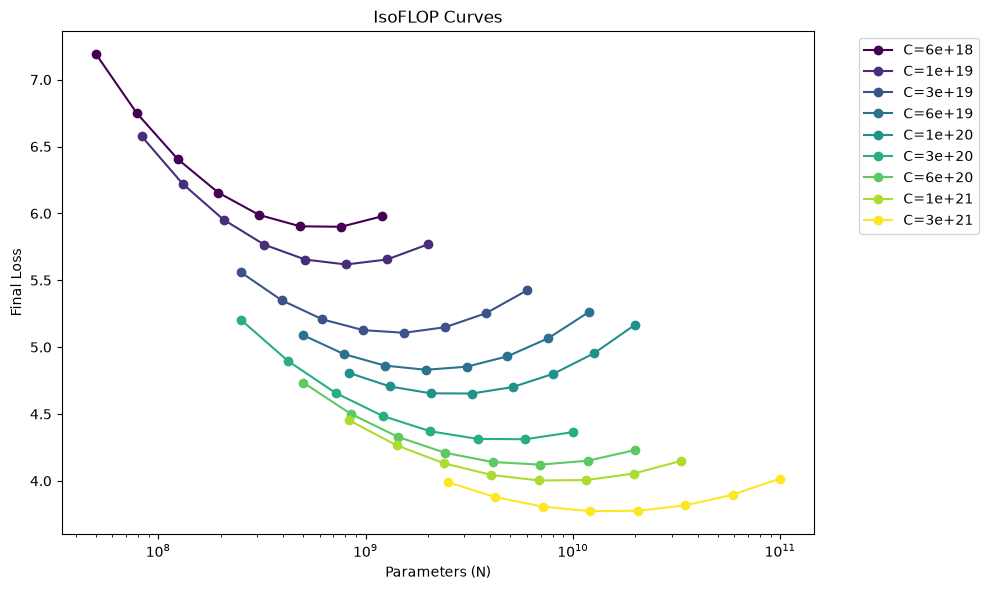

In [3]:
import matplotlib.pyplot as plt
import numpy as np

budgets = sorted(df["compute_budget"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(budgets)))

fig, ax = plt.subplots(figsize=(10, 6))
for budget, color in zip(budgets, colors):
    subset = df[df["compute_budget"] == budget].sort_values("parameters")
    ax.plot(subset["parameters"], subset["final_loss"], marker="o", color=color, label=f"C={budget:.0e}")

ax.set_xscale("log")
ax.set_xlabel("Parameters (N)")
ax.set_ylabel("Final Loss")
ax.set_title("IsoFLOP Curves")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 최적 모델 크기 N*(C)

In [4]:
optimal = df.loc[df.groupby("compute_budget")["final_loss"].idxmin()].copy()
optimal = optimal.sort_values("compute_budget").reset_index(drop=True)
optimal

,parameters,compute_budget,final_loss
0,762093419,6.000000e+18,5.899930
1,806647749,1.000000e+19,5.617943
2,1536852354,3.000000e+19,5.107177
3,1952041776,6.000000e+19,4.830586
4,3253402960,1.000000e+20,4.652893
5,5903836027,3.000000e+20,4.311219
6,6971055968,6.000000e+20,4.121241
7,6859328563,1.000000e+21,4.002835
8,12148905329,3.000000e+21,3.773188


## Power law fitting

In [5]:
log_C = np.log(optimal["compute_budget"].values)
log_N = np.log(optimal["parameters"].values)
log_D = np.log(optimal["compute_budget"].values / (6 * optimal["parameters"].values))

a, log_a0 = np.polyfit(log_C, log_N, 1)
b, log_b0 = np.polyfit(log_C, log_D, 1)

print(f"N* \u221d C^{a:.3f}  (Chinchilla: 0.490)")
print(f"D* \u221d C^{b:.3f}  (Chinchilla: 0.510)")
print(f"a + b = {a + b:.3f}")

N* ∝ C^0.469  (Chinchilla: 0.490)
D* ∝ C^0.531  (Chinchilla: 0.510)
a + b = 1.000


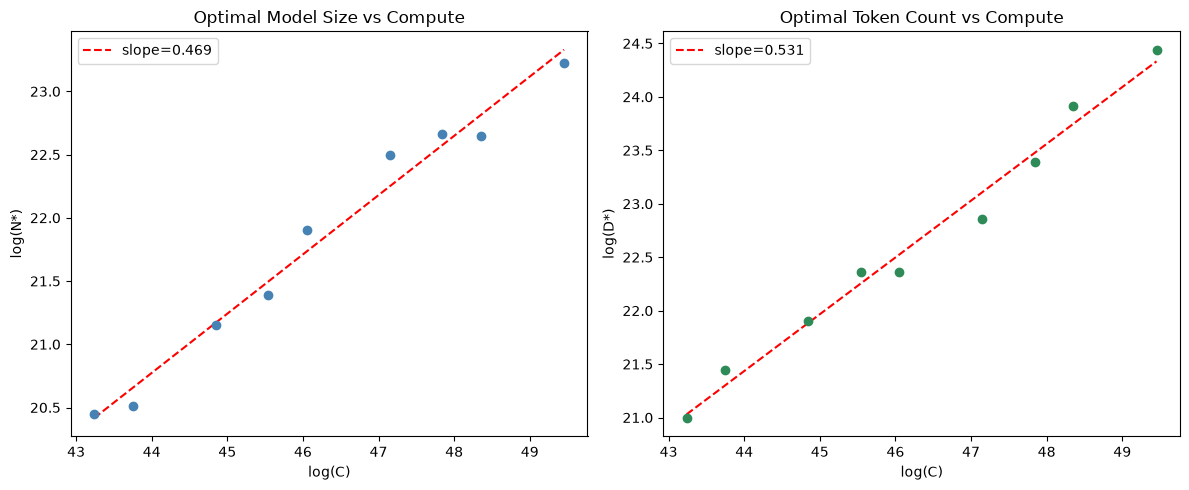

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
C_fit = np.linspace(log_C.min(), log_C.max(), 100)

axes[0].scatter(log_C, log_N, color="steelblue", zorder=5)
axes[0].plot(C_fit, a * C_fit + log_a0, "r--", label=f"slope={a:.3f}")
axes[0].set_xlabel("log(C)")
axes[0].set_ylabel("log(N*)")
axes[0].set_title("Optimal Model Size vs Compute")
axes[0].legend()

axes[1].scatter(log_C, log_D, color="seagreen", zorder=5)
axes[1].plot(C_fit, b * C_fit + log_b0, "r--", label=f"slope={b:.3f}")
axes[1].set_xlabel("log(C)")
axes[1].set_ylabel("log(D*)")
axes[1].set_title("Optimal Token Count vs Compute")
axes[1].legend()

plt.tight_layout()
plt.show()

## Tokens per parameter

In [7]:
optimal["D_star"] = optimal["compute_budget"] / (6 * optimal["parameters"])
optimal["tokens_per_param"] = optimal["D_star"] / optimal["parameters"]

print(optimal[["compute_budget", "parameters", "D_star", "tokens_per_param"]].to_string())
print(f"\naverage tokens/param: {optimal['tokens_per_param'].mean():.2f}")

   compute_budget   parameters        D_star  tokens_per_param
0    6.000000e+18    762093419  1.312175e+09          1.721803
1    1.000000e+19    806647749  2.066164e+09          2.561421
2    3.000000e+19   1536852354  3.253403e+09          2.116926
3    6.000000e+19   1952041776  5.122841e+09          2.624350
4    1.000000e+20   3253402960  5.122841e+09          1.574610
5    3.000000e+20   5903836027  8.469070e+09          1.434503
6    6.000000e+20   6971055968  1.434503e+10          2.057799
7    1.000000e+21   6859328563  2.429781e+10          3.542302
8    3.000000e+21  12148905329  4.115597e+10          3.387628

average tokens/param: 2.34


## 임의 compute budget에 대한 예측

In [8]:
A = np.exp(log_a0)


def predict_optimal(C_target):
    N_opt = A * C_target**a
    D_opt = C_target / (6 * N_opt)
    return N_opt, D_opt


for name, C_target in [("GPT-3", 3.15e23), ("Chinchilla", 5.76e23)]:
    N_opt, D_opt = predict_optimal(C_target)
    print(f"{name}: C={C_target:.2e}  N_opt={N_opt/1e9:.1f}B  D_opt={D_opt/1e9:.1f}B  tokens/param={D_opt/N_opt:.1f}")

GPT-3: C=3.15e+23  N_opt=119.9B  D_opt=437.7B  tokens/param=3.6
Chinchilla: C=5.76e+23  N_opt=159.2B  D_opt=603.2B  tokens/param=3.8
